# Treinamento e exportação do modelo de consumo energético

Este notebook treina e exporta uma formulação acionável: **nenhuma quantidade isolada de equipamentos ou lâmpadas é usada como feature**. Quantidades aparecem somente combinadas com frequência, duração ou intensidade de utilização.

O modelo é restrito a contas de até 400 kWh, faixa com suporte amostral suficiente. Acima desse limite, o retorno contém disclaimer de baixa confiabilidade.


In [1]:
from functools import partial
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder, RobustScaler
from xgboost import XGBRegressor
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType, StringTensorType
import onnxruntime as ort

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
SEMENTE = 42
ALVO = "alvo_mediana_consumo_kwh"
GRUPO = "municipio"
LIMITE_OPERACIONAL_KWH = 400.0
PASTA_RESULTADOS = Path("resultados_modelagem_uso")
PASTA_RESULTADOS.mkdir(exist_ok=True)


## Engenharia de features acionáveis

`numero_moradores` permanece porque representa pessoas, não itens possuídos. As quantidades de aparelhos são consumidas somente dentro das fórmulas de intensidade e removidas antes do treinamento. Variáveis de duração, frequência, clima e características do domicílio permanecem candidatas.


In [2]:
def carregar_e_criar_features(nome="dados_pph2019_tratados_regressao.csv"):
    dados = pd.read_csv(nome)
    moradores = dados["numero_moradores"].clip(lower=1)
    features = pd.DataFrame(index=dados.index)
    features["numero_moradores"] = dados["numero_moradores"]
    features["area_construida_m2"] = dados["area_construida_m2"]
    features["temperatura_media_2019_uf_c"] = dados["temperatura_media_2019_uf_c"]
    features["uf"] = dados["uf"]
    features["tipo_domicilio"] = dados["tipo_domicilio"]
    features["cor_paredes_externas"] = dados["cor_paredes_externas"]

    # Quantidade × uso: a posse nunca entra isoladamente.
    features["intensidade_ar_frequencia"] = (
        dados["numero_total_ar_condicionados"]
        * dados["frequencia_media_ar_condicionado_vezes_semana"]
    )
    features["intensidade_ar_horarios"] = (
        dados["numero_total_ar_condicionados"]
        * dados["horas_marcadas_ar_condicionado_semana_proxy"]
    )
    features["temperatura_configurada_ar_c"] = dados["temperatura_media_ar_condicionado_c"]
    features["intensidade_refrigeradores"] = (
        dados["numero_total_refrigeradores"]
        * dados["frequencia_total_refrigeradores_vezes_semana"]
    )
    features["intensidade_freezers"] = (
        dados["numero_total_freezers"]
        * dados["frequencia_total_freezers_vezes_semana"]
    )
    features["intensidade_televisores"] = (
        dados["numero_total_televisores"]
        * dados["horas_marcadas_televisores_semana_proxy"]
    )
    features["intensidade_microondas"] = (
        dados["numero_total_microondas"]
        * dados["minutos_microondas_semana_proxy"]
    )
    features["intensidade_maquina_lavar"] = (
        dados["numero_total_maquinas_lavar"]
        * dados["numero_lavagens_semana_proxy"]
    )
    features["intensidade_chuveiros"] = (
        dados["numero_total_chuveiros"] * dados["numero_banhos_dia"]
    )
    features["banhos_por_morador_dia"] = dados["numero_banhos_dia"] / moradores
    features["duracao_media_banho_min"] = dados["duracao_media_banho_min"]
    features["consumo_chuveiro_kwh_dia"] = dados["consumo_chuveiros_kwh_dia_proxy"]

    # Comportamentos diretamente informáveis, sem quantidade isolada de bens.
    features["frequencia_ar_semana"] = dados["frequencia_media_ar_condicionado_vezes_semana"]
    features["horarios_ar_semana"] = dados["horas_marcadas_ar_condicionado_semana_proxy"]
    features["horas_televisao_semana"] = dados["horas_marcadas_televisores_semana_proxy"]
    features["minutos_microondas_semana"] = dados["minutos_microondas_semana_proxy"]
    features["lavagens_semana"] = dados["numero_lavagens_semana_proxy"]
    features["frequencia_refrigeradores_semana"] = dados["frequencia_total_refrigeradores_vezes_semana"]
    features["frequencia_freezers_semana"] = dados["frequencia_total_freezers_vezes_semana"]

    # Intensidades normalizadas por ocupação ajudam a comparar famílias distintas.
    features["uso_ar_por_morador"] = features["intensidade_ar_frequencia"] / moradores
    features["televisao_por_morador"] = features["intensidade_televisores"] / moradores
    features["microondas_por_morador"] = features["intensidade_microondas"] / moradores
    features["lavagens_por_morador"] = features["intensidade_maquina_lavar"] / moradores
    features["chuveiro_kwh_por_morador"] = features["consumo_chuveiro_kwh_dia"] / moradores

    proibidas = [
        coluna for coluna in features
        if coluna.startswith("numero_total_") or "lampadas" in coluna
    ]
    if proibidas:
        raise AssertionError(f"Features de posse isolada encontradas: {proibidas}")
    return dados, features


dados, X_completo = carregar_e_criar_features()
y_completo = dados[ALVO].astype(float)
grupos_completos = dados[GRUPO].astype(str)
mascara_escopo = y_completo <= LIMITE_OPERACIONAL_KWH
X = X_completo.loc[mascara_escopo].reset_index(drop=True)
y = y_completo.loc[mascara_escopo].reset_index(drop=True)
grupos = grupos_completos.loc[mascara_escopo].reset_index(drop=True)
dados_escopo = dados.loc[mascara_escopo].reset_index(drop=True)

print(f"Candidatas acionáveis: {X.shape[1]}")
print(f"Residências no domínio: {len(X):,}")
print(f"Fora do domínio (> 400 kWh): {(~mascara_escopo).sum()}")
print("Features:", X.columns.tolist())


Candidatas acionáveis: 30
Residências no domínio: 2,331
Fora do domínio (> 400 kWh): 81
Features: ['numero_moradores', 'area_construida_m2', 'temperatura_media_2019_uf_c', 'uf', 'tipo_domicilio', 'cor_paredes_externas', 'intensidade_ar_frequencia', 'intensidade_ar_horarios', 'temperatura_configurada_ar_c', 'intensidade_refrigeradores', 'intensidade_freezers', 'intensidade_televisores', 'intensidade_microondas', 'intensidade_maquina_lavar', 'intensidade_chuveiros', 'banhos_por_morador_dia', 'duracao_media_banho_min', 'consumo_chuveiro_kwh_dia', 'frequencia_ar_semana', 'horarios_ar_semana', 'horas_televisao_semana', 'minutos_microondas_semana', 'lavagens_semana', 'frequencia_refrigeradores_semana', 'frequencia_freezers_semana', 'uso_ar_por_morador', 'televisao_por_morador', 'microondas_por_morador', 'lavagens_por_morador', 'chuveiro_kwh_por_morador']


## Visualização das intensidades e redundância


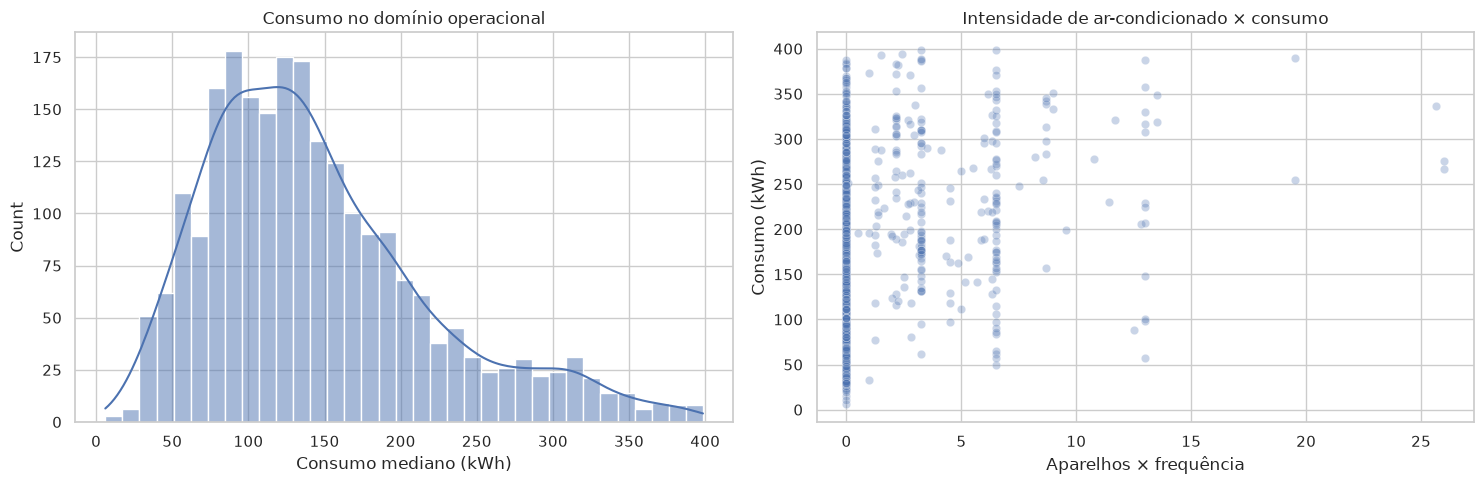

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(y, bins=35, kde=True, ax=axes[0])
axes[0].set(title="Consumo no domínio operacional", xlabel="Consumo mediano (kWh)")
sns.scatterplot(data=pd.DataFrame({"intensidade": X["intensidade_ar_frequencia"], "consumo": y}), x="intensidade", y="consumo", alpha=.3, ax=axes[1])
axes[1].set(title="Intensidade de ar-condicionado × consumo", xlabel="Aparelhos × frequência", ylabel="Consumo (kWh)")
fig.tight_layout(); plt.show()


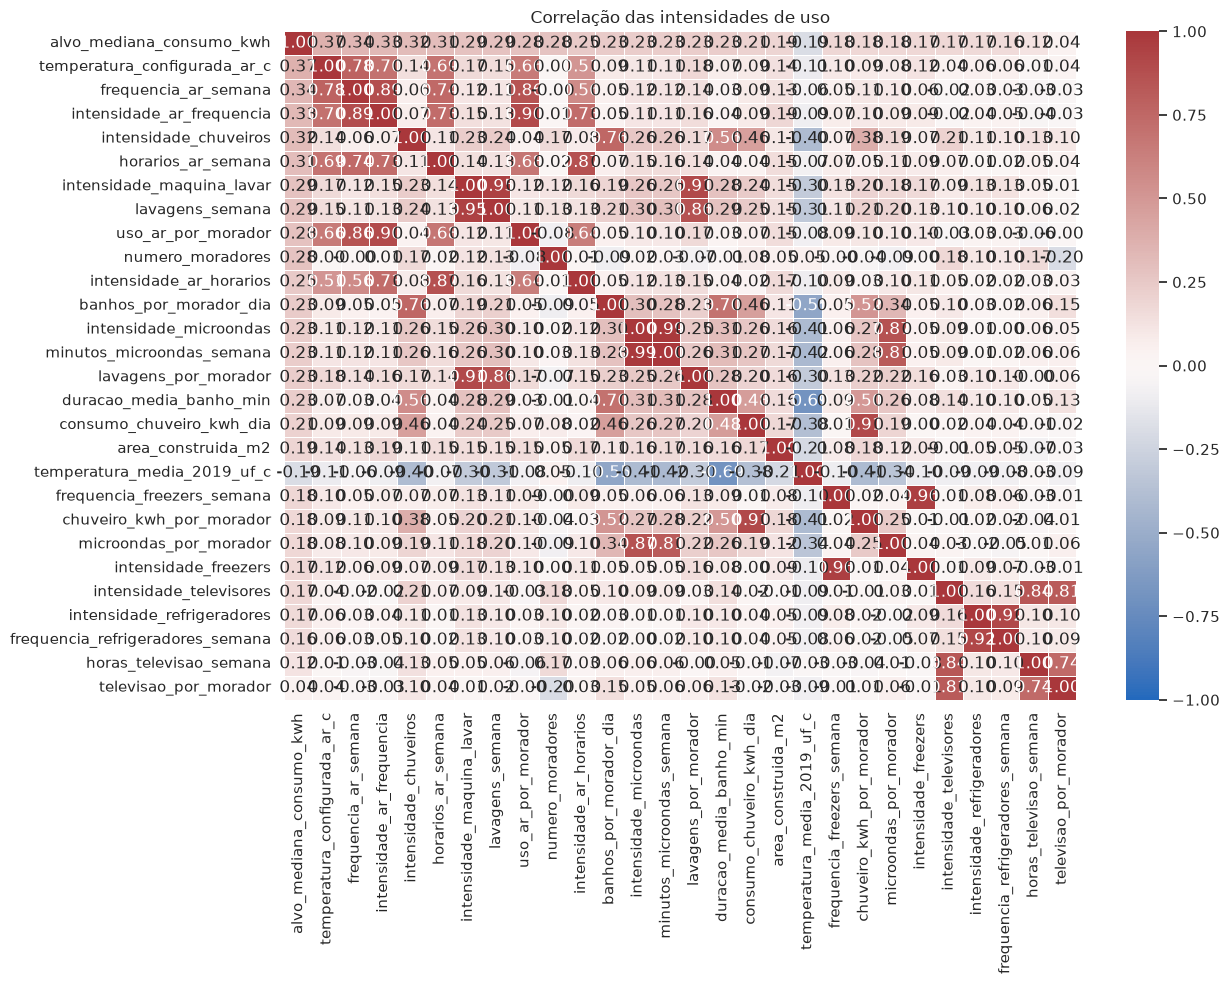

In [4]:
numericas = X.select_dtypes(include="number").columns
correlacoes = pd.concat([X[numericas], y.rename(ALVO)], axis=1).corr()
ordem = correlacoes[ALVO].abs().sort_values(ascending=False).index
plt.figure(figsize=(13, 10))
sns.heatmap(correlacoes.loc[ordem, ordem], cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=.4)
plt.title("Correlação das intensidades de uso")
plt.tight_layout(); plt.show()


## RFE com controle de redundância

Antes do RFE, o seletor preserva a candidata com maior relação absoluta com o alvo e rejeita outra candidata com correlação ≥ 0,80. O RFE então seleciona 8, 10, 12 ou no máximo 14 features dentro de cada fold.


In [5]:
class SeletorRFERedundancia(BaseEstimator, TransformerMixin):
    def __init__(self, k=7, correlacao_maxima=0.85, random_state=SEMENTE):
        self.k = k
        self.correlacao_maxima = correlacao_maxima
        self.random_state = random_state

    def fit(self, X, y):
        X_df = pd.DataFrame(X).copy()
        validas = X_df.columns[X_df.nunique(dropna=False) > 1]
        X_valido = X_df[validas]
        y_s = pd.Series(np.asarray(y), index=X_df.index)
        relacao_alvo = X_valido.apply(lambda c: c.corr(y_s)).abs().fillna(0)
        corr = X_valido.corr().abs().fillna(0)
        pre = []
        for nome in relacao_alvo.sort_values(ascending=False).index:
            if any(corr.loc[nome, anterior] >= self.correlacao_maxima for anterior in pre):
                continue
            pre.append(nome)
        if len(pre) < self.k:
            raise ValueError(f"Apenas {len(pre)} features não redundantes para k={self.k}")
        self.preselecionadas_ = np.asarray(pre)
        self.rfe_ = RFE(
            ExtraTreesRegressor(n_estimators=70, min_samples_leaf=4, random_state=self.random_state, n_jobs=1),
            n_features_to_select=self.k, step=.25,
        ).fit(X_df[self.preselecionadas_], y)
        escolhidas = set(self.preselecionadas_[self.rfe_.support_])
        self.feature_names_in_ = np.asarray(X_df.columns)
        self.support_ = np.asarray([c in escolhidas for c in X_df.columns])
        return self

    def transform(self, X):
        return pd.DataFrame(X).loc[:, self.support_]

    def get_support(self):
        return self.support_.copy()


def criar_preprocessador():
    nums = X.select_dtypes(include="number").columns.tolist()
    cats = X.select_dtypes(exclude="number").columns.tolist()
    pre = ColumnTransformer([
        ("numericas", Pipeline([("imputar", SimpleImputer(strategy="median")), ("escala", RobustScaler(quantile_range=(5, 95)))]), nums),
        ("categoricas", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")), ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)), ("escala", RobustScaler())]), cats),
    ], verbose_feature_names_out=False)
    return pre.set_output(transform="pandas")


def criar_pipeline(modelo):
    return Pipeline([
        ("preprocessamento", criar_preprocessador()),
        ("selecao", SeletorRFERedundancia(k=7)),
        ("modelo", TransformedTargetRegressor(regressor=modelo, check_inverse=False)),
    ])


def refit_parcimonioso(cv_results):
    rmse = -np.asarray(cv_results["mean_test_score"])
    limite = rmse.min() * 1.005
    elegiveis = np.flatnonzero(rmse <= limite)
    preferencia = {8: 0, 10: 1, 12: 2, 14: 3}
    return min(elegiveis, key=lambda i: (preferencia[cv_results["param_selecao__k"][i]], rmse[i]))


In [6]:
def configuracoes():
    alvo = [None, FunctionTransformer(np.log1p, inverse_func=np.expm1)]
    comum = {"selecao__k": [8, 10, 12, 14], "modelo__transformer": alvo}
    return {
        "KNN": (KNeighborsRegressor(), {**comum, "modelo__regressor__n_neighbors": [7, 11, 15, 21, 31], "modelo__regressor__weights": ["uniform", "distance"], "modelo__regressor__p": [1, 2]}),
        "RandomForest": (RandomForestRegressor(random_state=SEMENTE, n_jobs=-1), {**comum, "modelo__regressor__n_estimators": [350, 550, 750], "modelo__regressor__max_depth": [None, 8, 12, 16], "modelo__regressor__min_samples_leaf": [2, 4, 7], "modelo__regressor__max_features": [.5, .7, 1.0]}),
        "ExtraTrees": (ExtraTreesRegressor(random_state=SEMENTE, n_jobs=-1), {**comum, "modelo__regressor__n_estimators": [350, 550, 750], "modelo__regressor__max_depth": [None, 8, 12, 16], "modelo__regressor__min_samples_leaf": [2, 4, 7], "modelo__regressor__max_features": [.5, .7, 1.0]}),
        "XGBoost": (XGBRegressor(objective="reg:squarederror", random_state=SEMENTE, n_jobs=-1), {**comum, "modelo__regressor__n_estimators": [250, 400, 600], "modelo__regressor__learning_rate": [.02, .04, .07], "modelo__regressor__max_depth": [2, 3, 4], "modelo__regressor__min_child_weight": [3, 5, 8], "modelo__regressor__subsample": [.75, .9, 1.0], "modelo__regressor__colsample_bytree": [.7, .85, 1.0]}),
    }

split = GroupShuffleSplit(n_splits=1, test_size=.20, random_state=SEMENTE)
idx_treino, idx_teste = next(split.split(X, y, groups=grupos))
X_treino, X_teste = X.iloc[idx_treino], X.iloc[idx_teste]
y_treino, y_teste = y.iloc[idx_treino], y.iloc[idx_teste]
g_treino = grupos.iloc[idx_treino]
cv = GroupKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
buscas, linhas = {}, []
for nome, (modelo, params) in configuracoes().items():
    busca = RandomizedSearchCV(criar_pipeline(modelo), params, n_iter=24, scoring="neg_root_mean_squared_error", cv=cv, refit=refit_parcimonioso, random_state=SEMENTE, n_jobs=-1)
    busca.fit(X_treino, y_treino, groups=g_treino)
    pred = np.clip(busca.best_estimator_.predict(X_teste), 0, LIMITE_OPERACIONAL_KWH)
    buscas[nome] = busca
    linhas.append({"modelo": nome, "features": busca.best_estimator_.named_steps["selecao"].k, "rmse_cv_kwh": -busca.cv_results_["mean_test_score"][busca.best_index_], "rmse_holdout_kwh": mean_squared_error(y_teste, pred)**.5, "mae_holdout_kwh": mean_absolute_error(y_teste, pred), "r2_holdout": r2_score(y_teste, pred)})
metricas = pd.DataFrame(linhas).sort_values("rmse_cv_kwh", ignore_index=True)
metricas.round(4)


,modelo,features,rmse_cv_kwh,rmse_holdout_kwh,mae_holdout_kwh,r2_holdout
0,XGBoost,14,57.1047,71.8646,54.9677,0.1950
1,ExtraTrees,8,57.3190,71.4546,53.8204,0.2042
2,RandomForest,12,57.3796,70.5467,53.1313,0.2243
3,KNN,8,59.4708,72.1799,53.7912,0.1879


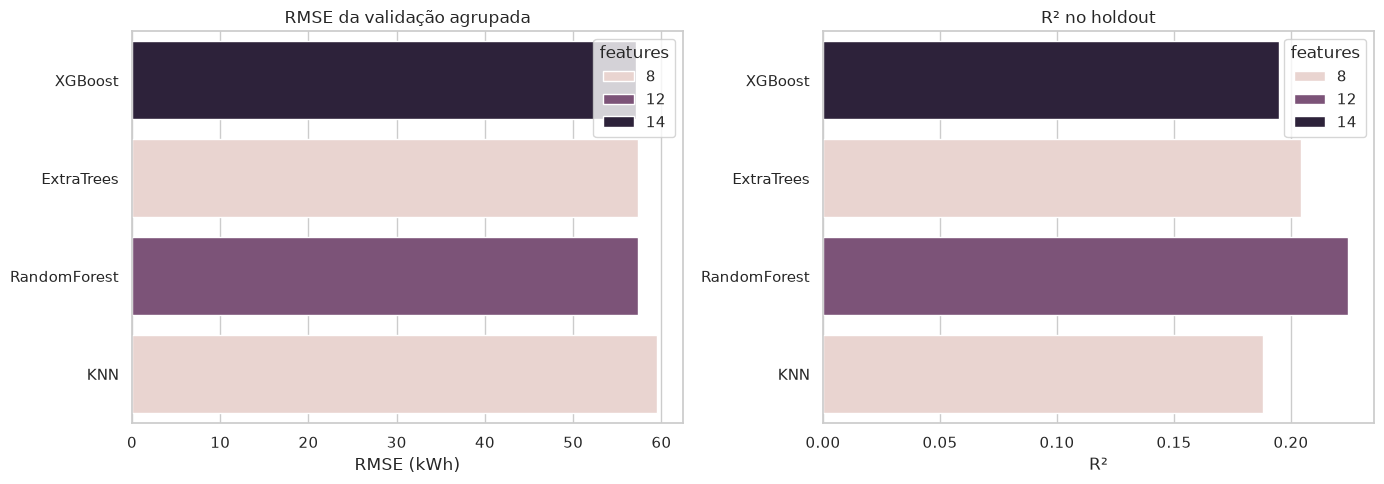

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=metricas, x="rmse_cv_kwh", y="modelo", hue="features", dodge=False, ax=axes[0])
axes[0].set(title="RMSE da validação agrupada", xlabel="RMSE (kWh)", ylabel="")
sns.barplot(data=metricas, x="r2_holdout", y="modelo", hue="features", dodge=False, ax=axes[1])
axes[1].set(title="R² no holdout", xlabel="R²", ylabel="")
fig.tight_layout(); plt.show()


## Diagnóstico, matriz por faixas e XAI

Como o alvo é contínuo, uma matriz de confusão convencional seria inadequada. Para atender ao diagnóstico visual sem alterar o problema, discretizamos **somente as previsões finais** em faixas de consumo. O treinamento e todas as métricas continuam sendo de regressão.


Escolha parcimoniosa global: ExtraTrees com 8 features; RMSE CV 57.32 kWh.


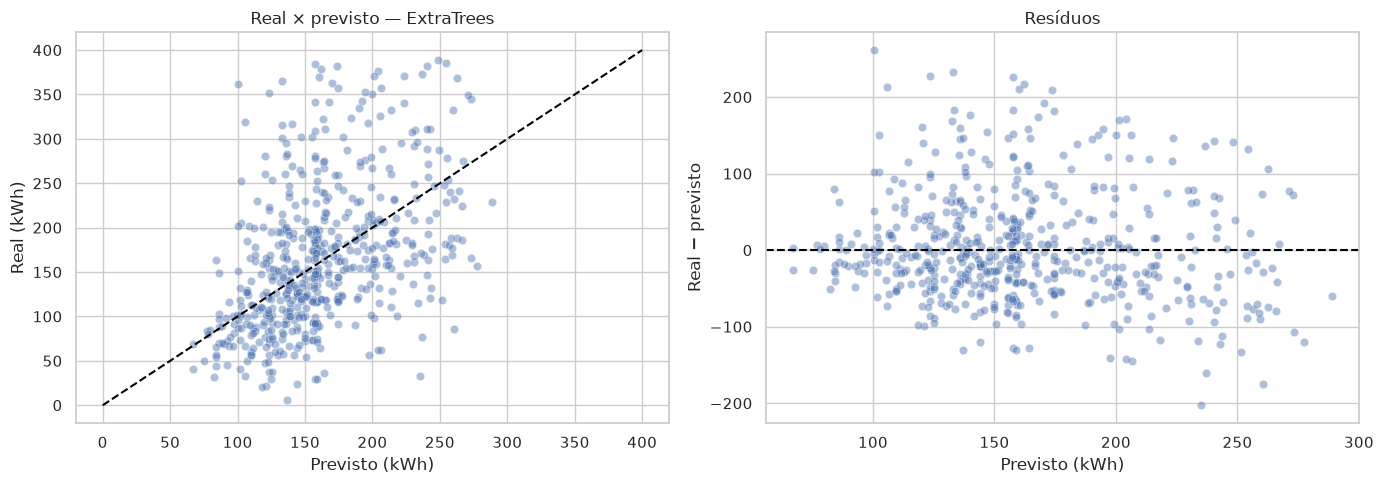

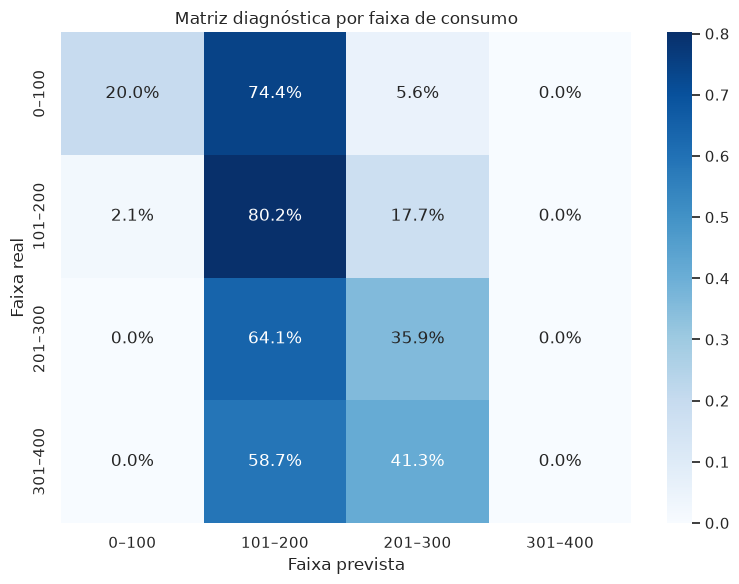

In [8]:
limite_global = metricas["rmse_cv_kwh"].min() * 1.005
candidatos_parcimoniosos = metricas.loc[metricas["rmse_cv_kwh"] <= limite_global]
escolha_global = candidatos_parcimoniosos.sort_values(
    ["features", "rmse_cv_kwh"], ascending=[True, True]
).iloc[0]
melhor_nome = escolha_global["modelo"]
melhor = buscas[melhor_nome].best_estimator_
print(
    f"Escolha parcimoniosa global: {melhor_nome} com {int(escolha_global['features'])} features; "
    f"RMSE CV {escolha_global['rmse_cv_kwh']:.2f} kWh."
)
pred = np.clip(melhor.predict(X_teste), 0, LIMITE_OPERACIONAL_KWH)
residuos = y_teste.to_numpy() - pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=pred, y=y_teste, alpha=.45, ax=axes[0]); axes[0].plot([0,400],[0,400],"--",color="black")
axes[0].set(title=f"Real × previsto — {melhor_nome}", xlabel="Previsto (kWh)", ylabel="Real (kWh)")
sns.scatterplot(x=pred, y=residuos, alpha=.45, ax=axes[1]); axes[1].axhline(0,ls="--",color="black")
axes[1].set(title="Resíduos", xlabel="Previsto (kWh)", ylabel="Real − previsto")
fig.tight_layout(); plt.show()

faixas=[0,100,200,300,401]; rotulos=["0–100","101–200","201–300","301–400"]
real_faixa=pd.cut(y_teste, bins=faixas, labels=rotulos, include_lowest=True)
pred_faixa=pd.cut(pred, bins=faixas, labels=rotulos, include_lowest=True)
matriz=confusion_matrix(real_faixa, pred_faixa, labels=rotulos, normalize="true")
plt.figure(figsize=(8,6)); sns.heatmap(matriz, annot=True, fmt=".1%", cmap="Blues", xticklabels=rotulos, yticklabels=rotulos)
plt.title("Matriz diagnóstica por faixa de consumo"); plt.xlabel("Faixa prevista"); plt.ylabel("Faixa real"); plt.tight_layout(); plt.show()


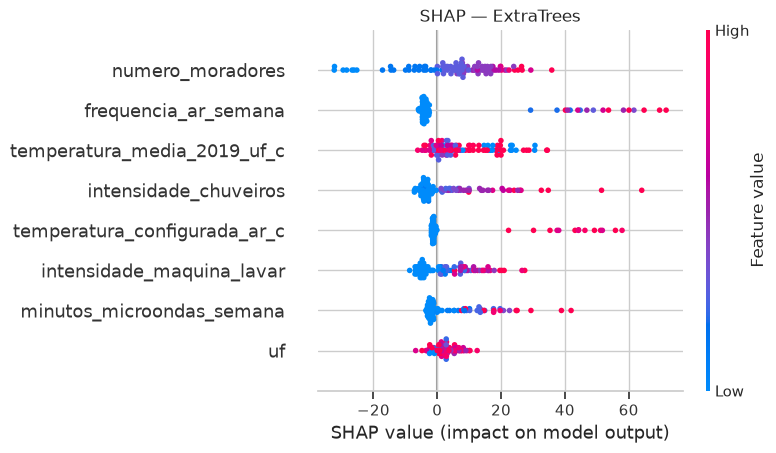

Features selecionadas: ['numero_moradores', 'temperatura_media_2019_uf_c', 'temperatura_configurada_ar_c', 'intensidade_maquina_lavar', 'intensidade_chuveiros', 'frequencia_ar_semana', 'minutos_microondas_semana', 'uf']
Features acionáveis: 5 de 8 ['temperatura_configurada_ar_c', 'intensidade_maquina_lavar', 'intensidade_chuveiros', 'frequencia_ar_semana', 'minutos_microondas_semana']


In [9]:
pre = melhor.named_steps["preprocessamento"].transform(X_teste)
sel = melhor.named_steps["selecao"].transform(pre)
sel.index = X_teste.index
modelo_interno = melhor.named_steps["modelo"]
fundo = shap.sample(melhor.named_steps["selecao"].transform(melhor.named_steps["preprocessamento"].transform(X_treino)), 50, random_state=SEMENTE)
amostra = shap.sample(sel, min(100,len(sel)), random_state=SEMENTE)
explicador = shap.Explainer(lambda z: modelo_interno.predict(np.asarray(z)), shap.maskers.Independent(fundo, max_samples=50), algorithm="permutation")
valores = explicador(amostra, max_evals=2*amostra.shape[1]+1, silent=True)
shap.plots.beeswarm(valores, max_display=12, show=False); plt.title(f"SHAP — {melhor_nome}"); plt.tight_layout(); plt.show()
print("Features selecionadas:", sel.columns.tolist())
features_acionaveis = [f for f in sel.columns if f not in {"numero_moradores", "area_construida_m2", "temperatura_media_2019_uf_c", "uf", "tipo_domicilio", "cor_paredes_externas"}]
print(f"Features acionáveis: {len(features_acionaveis)} de {len(sel.columns)}", features_acionaveis)


## Recomendações acionáveis por JSON e vizinhos KNN

As recomendações alteram somente comportamento: frequência, duração, horários e temperatura configurada. O sistema nunca recomenda remover lâmpadas ou aparelhos.


In [10]:
def preparar_json(payload):
    entrada=json.loads(payload) if isinstance(payload,str) else dict(payload)
    padroes={c:(float(X_treino[c].median()) if pd.api.types.is_numeric_dtype(X_treino[c]) else X_treino[c].mode().iloc[0]) for c in X.columns}
    linha=pd.DataFrame([{c:entrada.get(c,padroes[c]) for c in X.columns}])
    return entrada, linha

knn_busca=buscas["KNN"].best_estimator_
knn_preditor=knn_busca.named_steps["modelo"].regressor_


def calcular_eficiencia(consumo_referencia, mediana_vizinhos):
    razao = consumo_referencia / mediana_vizinhos if mediana_vizinhos > 0 else 1.0
    if razao <= 0.80:
        classe = "eficiente"
    elif razao > 1.20:
        classe = "ineficiente"
    else:
        classe = "normal"
    nota = float(np.clip(140 - 70 * razao, 0, 100))
    return razao, classe, nota


def prever_recomendar(payload):
    entrada, linha=preparar_json(payload)
    previsao=float(np.clip(melhor.predict(linha)[0],0,LIMITE_OPERACIONAL_KWH))
    ref_pre=knn_busca.named_steps["preprocessamento"].transform(X_treino)
    ref_sel=knn_busca.named_steps["selecao"].transform(ref_pre)
    item_sel=knn_busca.named_steps["selecao"].transform(knn_busca.named_steps["preprocessamento"].transform(linha))
    n=min(knn_preditor.n_neighbors,len(X_treino)); _,ind=knn_preditor.kneighbors(item_sel.to_numpy(),n_neighbors=n)
    viz=X_treino.iloc[ind[0]]
    recomendacoes=[]
    regras={
      "intensidade_ar_frequencia":("reduzir frequência/tempo de uso do ar-condicionado","reduzir"),
      "intensidade_ar_horarios":("reduzir faixas horárias de uso do ar-condicionado","reduzir"),
      "temperatura_configurada_ar_c":("elevar moderadamente a temperatura configurada do ar-condicionado","aumentar"),
      "intensidade_televisores":("reduzir horas de televisão","reduzir"),
      "intensidade_microondas":("reduzir minutos de uso do micro-ondas quando possível","reduzir"),
      "intensidade_maquina_lavar":("agrupar roupas e reduzir ciclos semanais","reduzir"),
      "banhos_por_morador_dia":("reduzir banhos excedentes por morador","reduzir"),
      "duracao_media_banho_min":("reduzir a duração média dos banhos","reduzir"),
      "consumo_chuveiro_kwh_dia":("reduzir tempo e potência usados no banho elétrico","reduzir"),
      "frequencia_ar_semana":("reduzir dias de uso do ar-condicionado","reduzir"),
      "horarios_ar_semana":("reduzir faixas horárias do ar-condicionado","reduzir"),
      "horas_televisao_semana":("reduzir horas semanais de televisão","reduzir"),
      "minutos_microondas_semana":("reduzir minutos semanais de micro-ondas quando possível","reduzir"),
      "lavagens_semana":("agrupar roupas e reduzir ciclos semanais","reduzir"),
      "uso_ar_por_morador":("reduzir o uso de ar-condicionado por morador","reduzir"),
      "televisao_por_morador":("reduzir horas de televisão por morador","reduzir"),
      "microondas_por_morador":("reduzir uso de micro-ondas por morador","reduzir"),
      "lavagens_por_morador":("reduzir ciclos de lavagem por morador","reduzir"),
      "chuveiro_kwh_por_morador":("reduzir energia de banho por morador","reduzir"),
    }
    selecionadas=set(item_sel.columns)
    for f,(acao,direcao) in regras.items():
      if f not in selecionadas: continue
      atual=float(linha.iloc[0][f]); med=float(viz[f].median())
      if (direcao=="reduzir" and atual>med) or (direcao=="aumentar" and atual<med):
        recomendacoes.append({"feature":f,"acao":acao,"valor_atual":round(atual,2),"referencia_vizinhos":round(med,2)})
    mediana_vizinhos = float(y_treino.iloc[ind[0]].median())
    consumo_real = entrada.get("consumo_atual_kwh")
    consumo_eficiencia = float(consumo_real) if consumo_real is not None else previsao
    razao, classe, nota = calcular_eficiencia(consumo_eficiencia, mediana_vizinhos)
    return {
      "previsao_kwh": round(previsao, 2),
      "consumo_usado_na_eficiencia_kwh": round(consumo_eficiencia, 2),
      "origem_consumo_eficiencia": "informado_pelo_usuario" if consumo_real is not None else "previsao_modelo",
      "mediana_vizinhos_kwh": round(mediana_vizinhos, 2),
      "razao_consumo_vizinhos": round(razao, 3),
      "classificacao_eficiencia": classe,
      "nota_eficiencia_0_100": round(nota, 1),
      "regra_nota": "nota = limitar(140 - 70 × razão, entre 0 e 100); razão 1 equivale a 70",
      "features_modelo": sel.columns.tolist(),
      "recomendacoes": recomendacoes,
      "metodo_explicacao": "comparação KNN com residências semelhantes e SHAP global no notebook",
      "disclaimer": "Modelo válido prioritariamente até 400 kWh; recomendações são associações com vizinhos, não efeitos causais garantidos."
    }

exemplo={"consumo_atual_kwh":310,"numero_moradores":4,"area_construida_m2":90,"uf":"CE","tipo_domicilio":"casa","cor_paredes_externas":"media","intensidade_ar_frequencia":12,"intensidade_ar_horarios":55,"temperatura_configurada_ar_c":19,"intensidade_televisores":40,"intensidade_microondas":30,"intensidade_maquina_lavar":8,"intensidade_chuveiros":10,"banhos_por_morador_dia":1.5,"duracao_media_banho_min":15,"consumo_chuveiro_kwh_dia":6,"frequencia_ar_semana":6,"horarios_ar_semana":28,"horas_televisao_semana":35,"minutos_microondas_semana":30,"lavagens_semana":7,"frequencia_refrigeradores_semana":7,"frequencia_freezers_semana":7,"uso_ar_por_morador":3,"televisao_por_morador":10,"microondas_por_morador":7.5,"lavagens_por_morador":2,"chuveiro_kwh_por_morador":1.5}
resultado_json=prever_recomendar(exemplo)
print(json.dumps(resultado_json,ensure_ascii=False,indent=2))


{
  "previsao_kwh": 254.72,
  "consumo_usado_na_eficiencia_kwh": 310.0,
  "origem_consumo_eficiencia": "informado_pelo_usuario",
  "mediana_vizinhos_kwh": 243.0,
  "razao_consumo_vizinhos": 1.276,
  "classificacao_eficiencia": "ineficiente",
  "nota_eficiencia_0_100": 50.7,
  "regra_nota": "nota = limitar(140 - 70 × razão, entre 0 e 100); razão 1 equivale a 70",
  "features_modelo": [
    "numero_moradores",
    "temperatura_media_2019_uf_c",
    "temperatura_configurada_ar_c",
    "intensidade_maquina_lavar",
    "intensidade_chuveiros",
    "frequencia_ar_semana",
    "minutos_microondas_semana",
    "uf"
  ],
  "recomendacoes": [
    {
      "feature": "temperatura_configurada_ar_c",
      "acao": "elevar moderadamente a temperatura configurada do ar-condicionado",
      "valor_atual": 19.0,
      "referencia_vizinhos": 22.0
    },
    {
      "feature": "intensidade_maquina_lavar",
      "acao": "agrupar roupas e reduzir ciclos semanais",
      "valor_atual": 8.0,
      "referencia

In [11]:
modelo_final = buscas[melhor_nome].best_estimator_.fit(X, y)
features_onnx = modelo_final.named_steps["preprocessamento"].get_feature_names_out()[
    modelo_final.named_steps["selecao"].get_support()
].tolist()

# O RFE customizado pertence apenas ao treinamento. Para implantação, reconstruímos
# um pipeline equivalente com as features finais e operadores ONNX suportados.
numericas_onnx = [c for c in features_onnx if pd.api.types.is_numeric_dtype(X[c])]
categoricas_onnx = [c for c in features_onnx if c not in numericas_onnx]
preprocessador_onnx = ColumnTransformer([
    ("numericas", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escala", RobustScaler(quantile_range=(5, 95))),
    ]), numericas_onnx),
    ("categoricas", Pipeline([
        # As categóricas finais não têm ausentes; remover o imputador mantém
        # compatibilidade com o conversor ONNX para tensores de strings.
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ("escala", RobustScaler()),
    ]), categoricas_onnx),
], verbose_feature_names_out=False)
regressor_onnx = clone(modelo_final.named_steps["modelo"].regressor_)
pipeline_onnx = Pipeline([
    ("preprocessamento", preprocessador_onnx),
    ("modelo", regressor_onnx),
]).fit(X[features_onnx], y)

initial_types = [
    (nome, FloatTensorType([None, 1])) if nome in numericas_onnx
    else (nome, StringTensorType([None, 1]))
    for nome in features_onnx
]
modelo_onnx = convert_sklearn(
    pipeline_onnx,
    name="EnergiAIFeaturesUso",
    initial_types=initial_types,
    target_opset=21,
)
caminho_onnx = PASTA_RESULTADOS / "modelo_features_uso.onnx"
caminho_onnx.write_bytes(modelo_onnx.SerializeToString())

# Equivalência numérica entre scikit-learn e ONNX.
amostra_validacao = X[features_onnx].head(50)
entradas_onnx = {
    nome: (
        amostra_validacao[[nome]].to_numpy(dtype=np.float32)
        if nome in numericas_onnx
        else amostra_validacao[[nome]].astype(str).to_numpy()
    )
    for nome in features_onnx
}
sessao = ort.InferenceSession(str(caminho_onnx), providers=["CPUExecutionProvider"])
predicao_onnx = np.asarray(sessao.run(None, entradas_onnx)[0]).reshape(-1)
predicao_sklearn = pipeline_onnx.predict(amostra_validacao)
diferenca_maxima = float(np.max(np.abs(predicao_onnx - predicao_sklearn)))
assert diferenca_maxima < 1e-3

manifesto = {
    "formato": "ONNX",
    "arquivo": "modelo_features_uso.onnx",
    "features_na_ordem": features_onnx,
    "features_numericas": numericas_onnx,
    "features_categoricas": categoricas_onnx,
    "output": "consumo_estimado_kwh",
    "limite_operacional_kwh": LIMITE_OPERACIONAL_KWH,
    "diferenca_maxima_sklearn_onnx_kwh": diferenca_maxima,
    "regra_eficiencia": {
        "eficiente": "razao <= 0.80",
        "normal": "0.80 < razao <= 1.20",
        "ineficiente": "razao > 1.20",
        "nota": "clip(140 - 70 * razao, 0, 100)",
    },
}
(PASTA_RESULTADOS / "manifesto_onnx.json").write_text(
    json.dumps(manifesto, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
)
(PASTA_RESULTADOS / "exemplo_entrada.json").write_text(json.dumps(exemplo, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
(PASTA_RESULTADOS / "exemplo_saida.json").write_text(json.dumps(resultado_json, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print(f"ONNX validado; diferença máxima: {diferenca_maxima:.6f} kWh")
print("Experimento concluído; artefatos salvos em resultados_modelagem_uso/.")


ONNX validado; diferença máxima: 0.000176 kWh
Experimento concluído; artefatos salvos em resultados_modelagem_uso/.
